In [1]:
import pm4py

ocel = pm4py.read_ocel2_xml("socel2_hinge.xml")
print(type(ocel))



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




<class 'pm4py.objects.ocel.obj.OCEL'>


In [2]:
# Events table
print(ocel.events.head())

# Objects table
print(ocel.objects.head())

# How many events and objects total?
print(f"Events: {len(ocel.events)}")
print(f"Objects: {len(ocel.objects)}")

    ocel:eid    ocel:activity            ocel:timestamp  p_duration[s]  \
0  e_split_1  SplitSteelSheet 2023-04-03 07:38:46+00:00  6.45815106562   
1  e_split_2  SplitSteelSheet 2023-04-03 07:38:53+00:00  6.66942626174   
2  e_split_3  SplitSteelSheet 2023-04-03 07:38:59+00:00  6.46127402273   
3  e_split_4  SplitSteelSheet 2023-04-03 07:39:06+00:00  6.56081527807   
4  e_split_5  SplitSteelSheet 2023-04-03 07:39:12+00:00   6.5291579575   

     s_co2e[kg]  i_electric-from-grid-de[kWh]  i_steel-waste-to-recycle[kg]  \
0  0.0067576962                      0.009867                       0.00042   
1  0.0069784914                      0.010189                       0.00042   
2  0.0067609794                      0.009871                       0.00042   
3  0.0068650158                      0.010023                       0.00042   
4  0.0068319102                      0.009975                       0.00042   

   i_gas_input[Wh]  i_emission-of-burn[Wh]  i_coating-material[kg]  \
0         

In [3]:
print(ocel.objects['ocel:type'].unique())

<StringArray>
[   'Facility',  'FemalePart',  'FormedPart',       'Hinge',   'HingePack',
     'Machine',    'MalePart',   'SteelCoil',    'SteelPin',  'SteelSheet',
      'Worker', 'Workstation']
Length: 12, dtype: str


In [4]:
print(ocel.events['ocel:activity'].unique())

<StringArray>
['SplitSteelSheet',  'HeatSteelSheet',  'FormSteelSheet',        'CoatPart',
       'MoveParts',  'CuttFemalePart',    'CuttMalePart', 'CheckFemalePart',
   'CheckMalePart',   'AssembleHinge',      'PackHinges']
Length: 11, dtype: str


In [5]:
ocdfg = pm4py.discover_ocdfg(ocel)

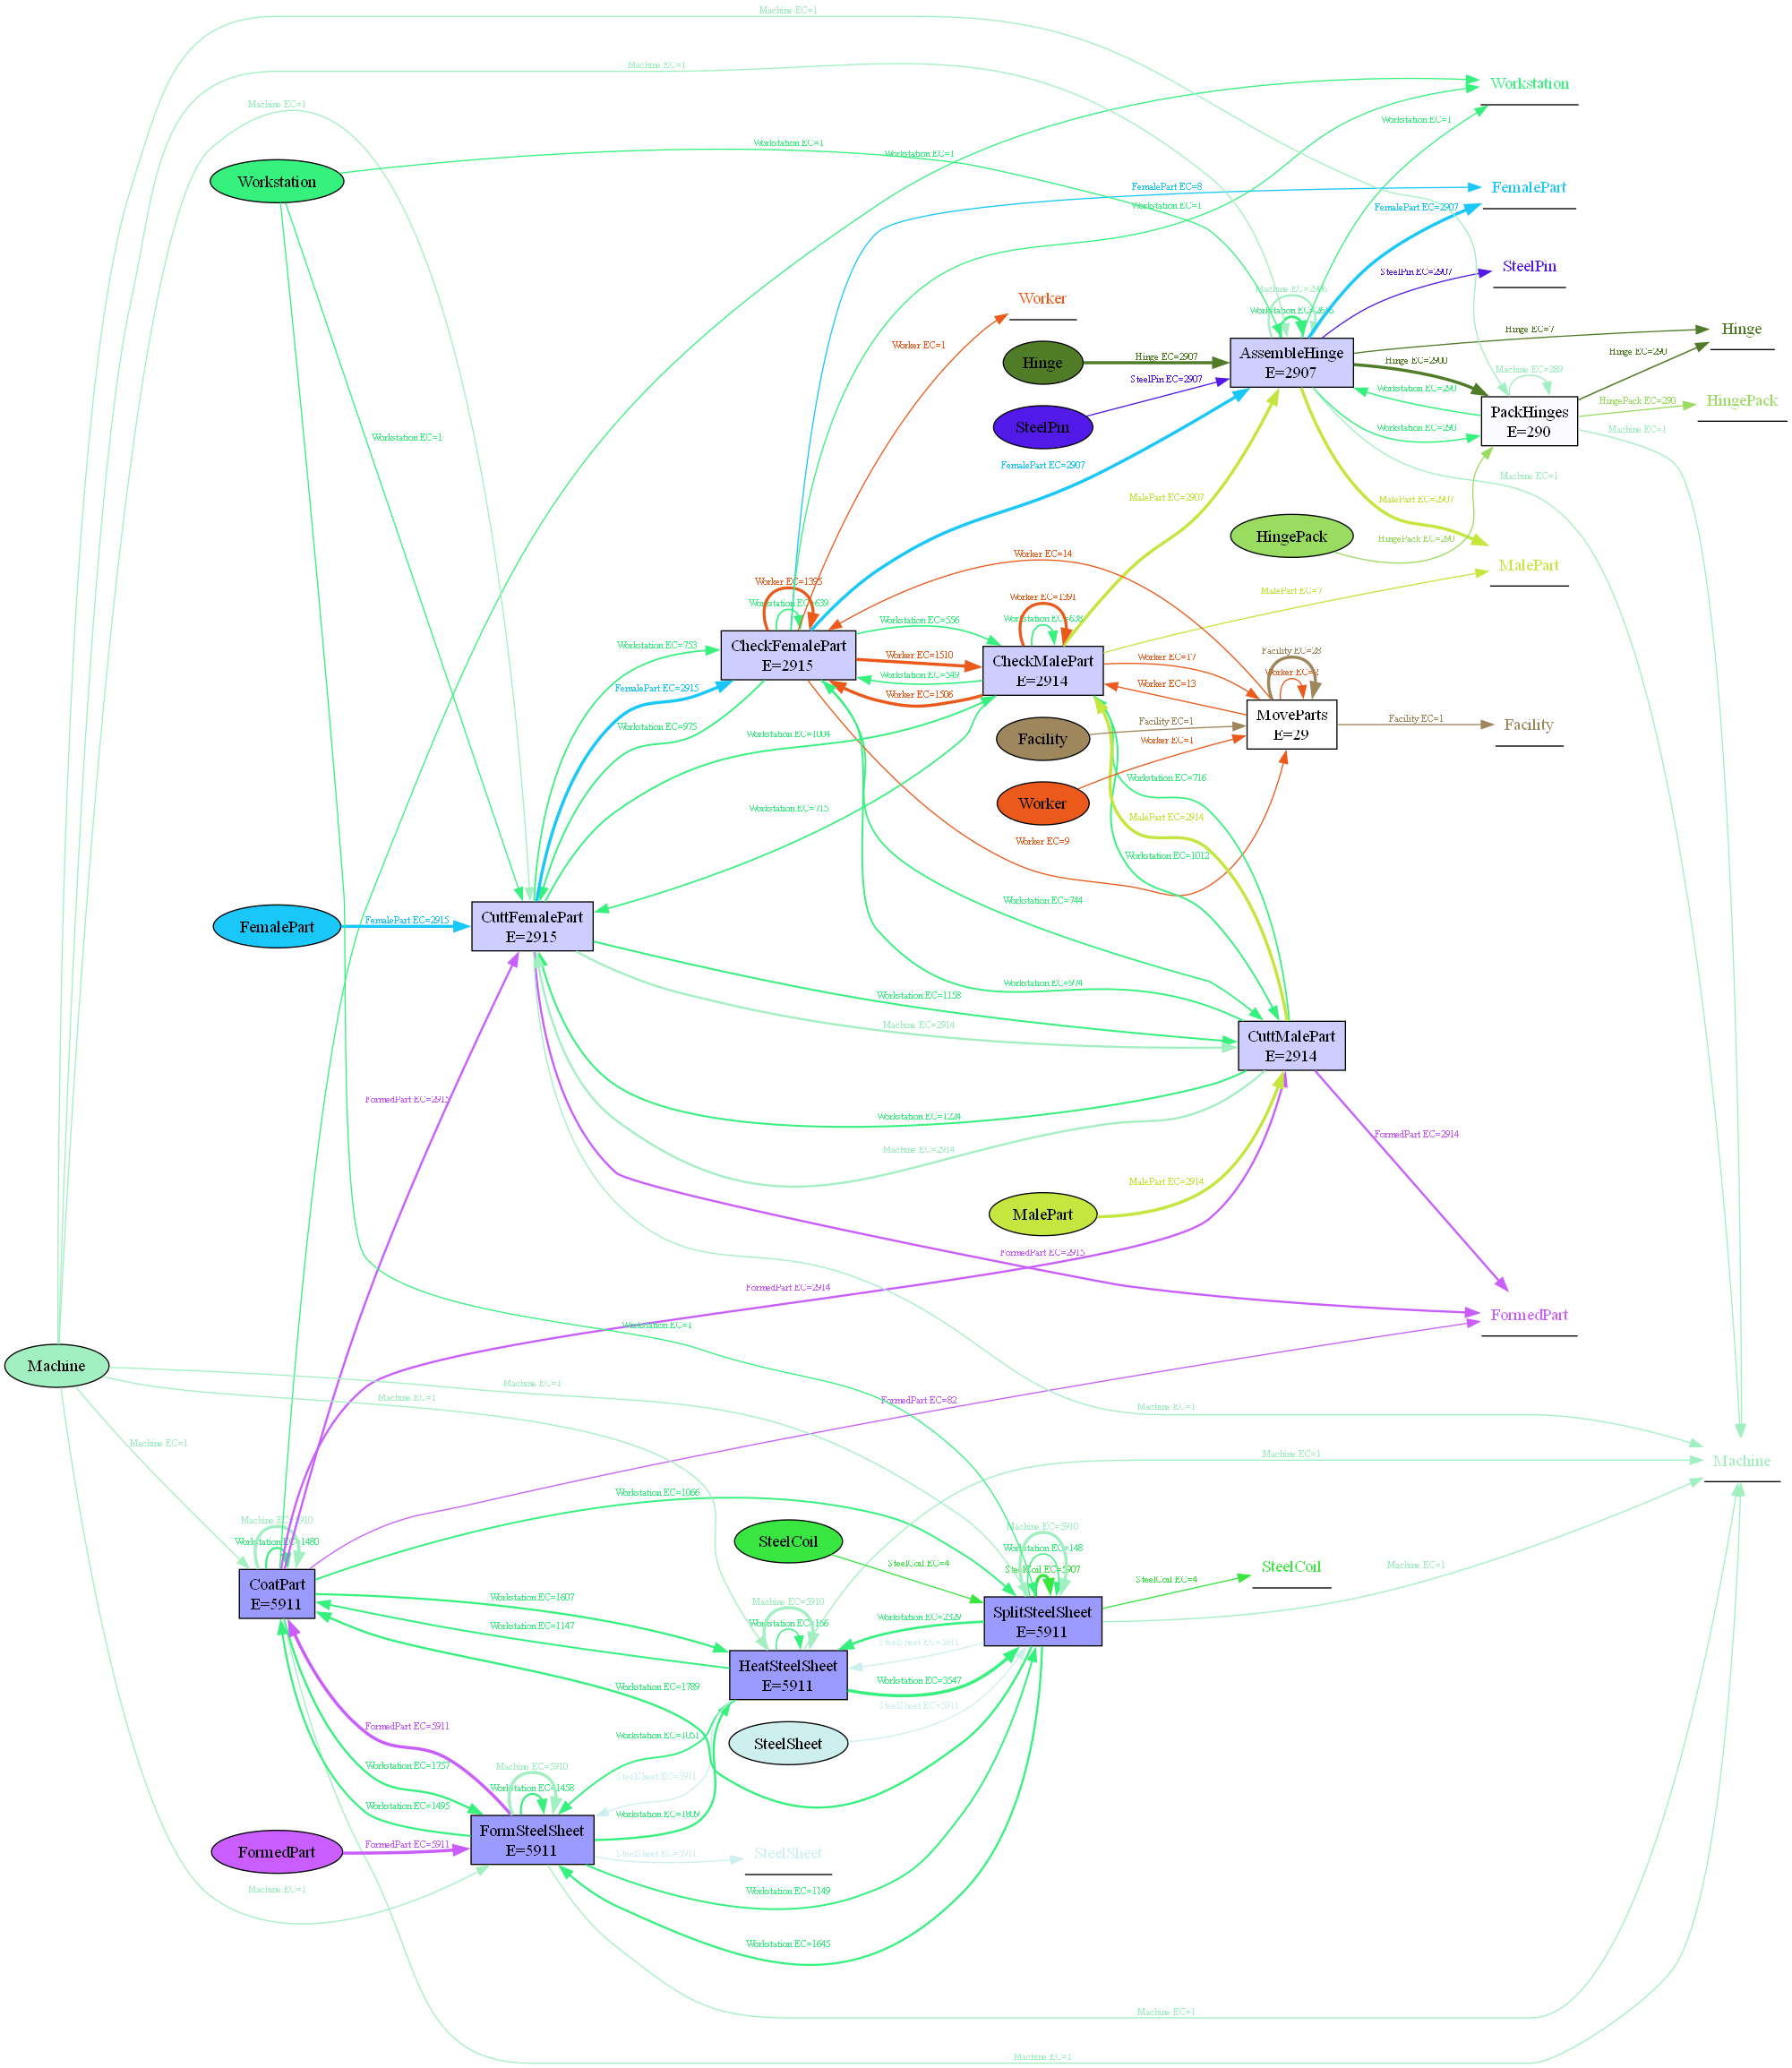

In [6]:
pm4py.view_ocdfg(ocdfg)

In [7]:
pm4py.save_vis_ocdfg(ocdfg, "process_map.png")

''

In [8]:
# How many objects of each type are involved on average per event
import pandas as pd
print(ocel.relations.groupby('ocel:activity')['ocel:oid'].count())

ocel:activity
AssembleHinge      17442
CheckFemalePart     8745
CheckMalePart       8742
CoatPart           17733
CuttFemalePart     11660
CuttMalePart       11656
FormSteelSheet     23644
HeatSteelSheet     17733
MoveParts             58
PackHinges          3770
SplitSteelSheet    23644
Name: ocel:oid, dtype: int64
